In [25]:
import os

In [35]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import MemorySaver

In [27]:
from dotenv import load_dotenv

In [28]:
load_dotenv()  # Load environment variables from .env file

True

In [37]:
llm = ChatOllama(model='llama3.2')

In [38]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [39]:
def chat_node(state: ChatState):
    #take user query from state
    messages = state['messages']
    # send to llm
    response = llm.invoke(messages)
    # response store state
    return {'messages': [response]}


In [ ]:
checkpoint = MemorySaver()

graph = StateGraph(ChatState)

## add nodes
graph.add_node('chat_node', chat_node)

#add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()

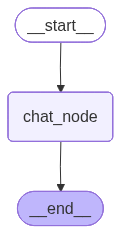

In [33]:
chatbot

In [43]:
initial_state = {
    'messages':[HumanMessage(content="what is the object oriented programming in python?")]
}

response = chatbot.invoke(initial_state)

response['messages']

[HumanMessage(content='what is the object oriented programming in python?', additional_kwargs={}, response_metadata={}, id='dfed91e5-6e7e-40f9-a9ed-f2a156cd455e'),
 AIMessage(content='Object-Oriented Programming (OOP) in Python\n=============================================\n\nPython is an object-oriented language, supporting various principles and concepts of OOP. Here\'s a brief overview:\n\n**Key Principles of OOP:**\n\n### 1. Encapsulation\n\nEncapsulation is the concept of bundling data and methods that operate on that data into a single unit, called a class.\n\n```python\nclass BankAccount:\n    def __init__(self, balance):\n        self.__balance = balance  # private attribute\n\n    def deposit(self, amount):\n        self.__balance += amount\n\n    def get_balance(self):\n        return self.__balance\n```\n\nIn this example, `BankAccount` is a class that encapsulates the data (`__balance`) and methods (`deposit`, `get_balance`) that operate on it.\n\n### 2. Inheritance\n\nInh

In [44]:
response['messages'][-1]

AIMessage(content='Object-Oriented Programming (OOP) in Python\n=============================================\n\nPython is an object-oriented language, supporting various principles and concepts of OOP. Here\'s a brief overview:\n\n**Key Principles of OOP:**\n\n### 1. Encapsulation\n\nEncapsulation is the concept of bundling data and methods that operate on that data into a single unit, called a class.\n\n```python\nclass BankAccount:\n    def __init__(self, balance):\n        self.__balance = balance  # private attribute\n\n    def deposit(self, amount):\n        self.__balance += amount\n\n    def get_balance(self):\n        return self.__balance\n```\n\nIn this example, `BankAccount` is a class that encapsulates the data (`__balance`) and methods (`deposit`, `get_balance`) that operate on it.\n\n### 2. Inheritance\n\nInheritance allows one class to inherit properties and behavior from another class.\n\n```python\nclass Animal:\n    def __init__(self, name):\n        self.name = name

In [48]:
thread_id = "1"
while True:
    user_message = input("Type here:")
    print("User message:", user_message)

    if user_message.strip().lower() in ['exit', 'quit','bye ']:
        break
    config = {"configurable":{"thread_id": thread_id}}
    response = chatbot.invoke({'messages':[HumanMessage(content=user_message)]})
    print("AI: ",response['messages'][-1].content)


User message: my name is thilan
AI:  Hello Thilan! It's nice to meet you. Is there something I can help you with, or would you like to chat?
User message: I want to know how to become an AI engineer
AI:  Becoming an AI engineer requires a combination of technical skills, knowledge, and experience. Here's a step-by-step guide to help you get started:

**Prerequisites**

1. **Programming skills**: Proficiency in one or more programming languages such as Python, Java, C++, or JavaScript is essential.
2. **Mathematics and statistics**: Understanding linear algebra, calculus, probability theory, and statistics is crucial for AI engineering.
3. **Computer vision and machine learning basics**: Familiarity with basic concepts like supervised and unsupervised learning, neural networks, deep learning, and computer vision.

**Step 1: Learn the Fundamentals**

1. **Take online courses**:
	* Coursera's Machine Learning course by Andrew Ng
	* Stanford University's CS231n: Convolutional Neural Networ

In [49]:
thread_id = "2"
initial_state = {
    'messages': [HumanMessage(content='What is my name?')]
}

config = {'configurable': {'thread_id': thread_id}}
response = chatbot.invoke(initial_state, config=config)

In [50]:
response['messages'][-1].content

"I don't have any information about your personal details, including your name. Our conversation just started, and I'm a large language model, I don't have the ability to store or retain any information about individual users. Each time you interact with me, it's a new conversation. If you'd like to share your name with me, I'd be happy to chat with you!"